# 💰 Financial Dataset — Data Cleaning & Exploratory Data Analysis

**Dataset:** S&P 500 Companies Financial Data (sourced from [Kaggle — S&P 500 Stocks Dataset](https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks))  
**Goal:** Simulate a realistically messy financial dataset, perform thorough data cleaning, anomaly detection, and EDA to extract key business insights.

---
### Notebook Structure
1. Dataset Generation (simulated messy real-world data)
2. Initial Inspection
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Anomaly & Error Detection
6. Key Insights & Summary

## 1. Setup & Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility
np.random.seed(42)

# ── Plot style
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold'
})

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ══════════════════════════════════════════════════════════════
#  Simulate a messy S&P 500 financial dataset (500 companies)
# ══════════════════════════════════════════════════════════════

SECTORS = ['Technology', 'Healthcare', 'Financials', 'Consumer Discretionary',
           'Industrials', 'Communication Services', 'Consumer Staples',
           'Energy', 'Utilities', 'Real Estate', 'Materials']

TICKERS = [f'TICK{i:03d}' for i in range(500)]

n = 500

revenue        = np.random.lognormal(mean=7.5, sigma=1.8, size=n) * 1e6
net_income     = revenue * np.random.normal(0.08, 0.12, n)
total_assets   = revenue * np.random.uniform(0.8, 4.0, n)
total_liab     = total_assets * np.random.uniform(0.3, 0.9, n)
equity         = total_assets - total_liab
mkt_cap        = revenue * np.random.uniform(1.0, 8.0, n)
pe_ratio       = np.random.lognormal(2.8, 0.7, n)
eps            = net_income / (mkt_cap / np.random.uniform(20, 80, n))
debt_to_equity = total_liab / np.where(equity > 0, equity, 1)
roe            = net_income / np.where(equity > 0, equity, 1)
shares         = mkt_cap / np.random.uniform(20, 120, n)
dividend_yield = np.random.choice([0]*3 + list(np.random.uniform(0.5, 6.0, n)), n)
year           = np.random.choice([2020, 2021, 2022, 2023], n)

df_raw = pd.DataFrame({
    'Ticker':          TICKERS,
    'Sector':          np.random.choice(SECTORS, n),
    'Year':            year,
    'Revenue':         revenue,
    'Net_Income':      net_income,
    'Total_Assets':    total_assets,
    'Total_Liabilities': total_liab,
    'Equity':          equity,
    'Market_Cap':      mkt_cap,
    'PE_Ratio':        pe_ratio,
    'EPS':             eps,
    'Debt_to_Equity':  debt_to_equity,
    'ROE':             roe,
    'Shares_Outstanding': shares,
    'Dividend_Yield':  dividend_yield
})

# ── Inject realistic MESS ──────────────────────────────────────
mess_idx = np.random.choice(n, size=int(n * 0.08), replace=False)
df_raw.loc[mess_idx[:15], 'Revenue']      = np.nan
df_raw.loc[mess_idx[15:28], 'PE_Ratio']   = np.nan
df_raw.loc[mess_idx[28:35], 'Net_Income'] = np.nan
df_raw.loc[mess_idx[35:40], 'EPS']        = np.nan

# Extreme outliers
df_raw.loc[0,  'PE_Ratio']    = 9999.0          # data entry error
df_raw.loc[1,  'Revenue']     = -5_000_000      # negative revenue (error)
df_raw.loc[2,  'Market_Cap']  = 0.0             # zero market cap
df_raw.loc[3,  'Debt_to_Equity'] = 500.0        # extreme leverage
df_raw.loc[4,  'Dividend_Yield'] = 150.0        # impossible yield

# Duplicate rows
dup_rows = df_raw.iloc[10:14].copy()
df_raw = pd.concat([df_raw, dup_rows], ignore_index=True)

# String contamination in numeric column
df_raw['Revenue'] = df_raw['Revenue'].astype(object)
df_raw.loc[20, 'Revenue'] = 'N/A'
df_raw.loc[21, 'Revenue'] = '$2,500,000'
df_raw.loc[22, 'Revenue'] = ''

# Sector typo / inconsistency
df_raw.loc[50, 'Sector']  = 'technology'         # lowercase
df_raw.loc[51, 'Sector']  = 'FINANCIALS'          # uppercase
df_raw.loc[52, 'Sector']  = 'Tech'                # abbreviation
df_raw.loc[53, 'Sector']  = ' Healthcare '        # whitespace

print(f'Raw dataset shape: {df_raw.shape}')
df_raw.head(10)

Raw dataset shape: (504, 15)


,Ticker,Sector,Year,Revenue,Net_Income,Total_Assets,Total_Liabilities,Equity,Market_Cap,PE_Ratio,EPS,Debt_to_Equity,ROE,Shares_Outstanding,Dividend_Yield
0,TICK000,Utilities,2022,4420842091.7471,8.450055e+08,5.905999e+09,4.310163e+09,1.595836e+09,1.120012e+10,9999.000000,5.056722,2.700881,0.529506,9.607677e+07,5.812078
1,TICK001,Real Estate,2022,-5000000.0,4.357771e+08,1.599457e+09,5.490146e+08,1.050442e+09,1.772049e+09,10.346129,13.272354,0.522651,0.414851,2.977456e+07,1.306823
2,TICK002,Industrials,2023,5801311946.228252,-5.095183e+08,1.645587e+10,5.640315e+09,1.081555e+10,0.000000e+00,22.156281,-1.938755,0.521500,-0.047110,1.097422e+08,3.094072
3,TICK003,Healthcare,2021,28041861928.636894,4.137754e+09,8.582835e+10,2.637206e+10,5.945630e+10,9.455785e+10,16.666545,2.593179,500.000000,0.069593,1.732444e+09,0.827895
4,TICK004,Real Estate,2020,1186216282.003698,2.280965e+06,1.068871e+09,9.340869e+08,1.347837e+08,7.850498e+09,10.495632,0.009856,6.930267,0.016923,9.012237e+07,150.000000
5,TICK005,Communication Services,2022,1186251337.577508,2.555773e+07,4.502867e+09,3.343401e+09,1.159466e+09,5.936406e+09,23.138794,0.089820,2.883571,0.022043,5.904345e+07,1.033311
6,TICK006,Consumer Staples,2023,31026069072.920277,2.765269e+08,2.998074e+10,1.534867e+10,1.463208e+10,1.423685e+11,58.151035,0.127924,1.048974,0.018899,1.241489e+09,3.636578
7,TICK007,Healthcare,2023,7196733435.019291,-1.704107e+08,1.822320e+10,8.709254e+09,9.513942e+09,2.198186e+10,14.387609,-0.445174,0.915420,-0.017912,3.662347e+08,2.234501
8,TICK008,Healthcare,2023,776616066.48215,6.665121e+07,2.383430e+09,1.215125e+09,1.168305e+09,5.841920e+09,27.216695,0.750015,1.040075,0.057049,5.941150e+07,0.737051
9,TICK009,Real Estate,2022,4801137166.16355,-9.464969e+07,1.722216e+10,1.317138e+10,4.050789e+09,1.814400e+10,6.650612,-0.116519,3.251558,-0.023366,3.894161e+08,1.713581


## 2. Initial Inspection

In [3]:
print('='*55)
print('SHAPE:', df_raw.shape)
print('='*55)
df_raw.info()

SHAPE: (504, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ticker              504 non-null    object 
 1   Sector              504 non-null    object 
 2   Year                504 non-null    int64  
 3   Revenue             489 non-null    object 
 4   Net_Income          497 non-null    float64
 5   Total_Assets        504 non-null    float64
 6   Total_Liabilities   504 non-null    float64
 7   Equity              504 non-null    float64
 8   Market_Cap          504 non-null    float64
 9   PE_Ratio            491 non-null    float64
 10  EPS                 499 non-null    float64
 11  Debt_to_Equity      504 non-null    float64
 12  ROE                 504 non-null    float64
 13  Shares_Outstanding  504 non-null    float64
 14  Dividend_Yield      504 non-null    float64
dtypes: float64(11), int64(1), object(3)
memo

In [5]:
# Missing values overview
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_%': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0]
print('\n── Missing Values ──')
print(missing_df.to_string())


── Missing Values ──
            Missing_Count  Missing_%
Revenue                15       2.98
Net_Income              7       1.39
PE_Ratio               13       2.58
EPS                     5       0.99


In [6]:
# Duplicate rows check
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

# Unique sectors (spot typos)
print('\n── Unique Sector Values ──')
print(df_raw['Sector'].unique())

Duplicate rows: 4

── Unique Sector Values ──
['Utilities' 'Real Estate' 'Industrials' 'Healthcare'
 'Communication Services' 'Consumer Staples' 'Technology'
 'Consumer Discretionary' 'Financials' 'Materials' 'Energy' 'technology'
 'FINANCIALS' 'Tech' ' Healthcare ']


In [7]:
# Basic statistics on numeric columns
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max'])

,count,mean,std,min,25%,50%,75%,max
Year,504.000000,2021.501984,1.129751,2020.000000,2020.000000,2022.000000,2023.000000,2023.000000
Net_Income,497.000000,1551652026.902389,23936189827.215656,-50783745460.294212,2874405.012697,78307105.192531,309349409.942714,526832115889.840515
Total_Assets,504.000000,29264947320.496620,191468925763.591644,18447337.308512,1075344924.402275,4030867585.675727,12139975313.466709,3857276137732.789551
Total_Liabilities,504.000000,19336641980.970345,146532452052.110046,12739437.469009,641304602.874581,2317275095.638032,7403992642.573191,2914708119316.169434
Equity,504.000000,9928305339.526279,48502269377.340523,5707899.839503,377070353.010100,1320306962.220953,5323685770.434987,942568018416.620117
Market_Cap,504.000000,43606567850.639381,202162247581.276947,0.000000,1928256997.219702,6313393484.588376,25058161532.342075,3278780410129.413574
PE_Ratio,491.000000,41.466174,450.604269,2.598610,10.367189,17.027703,26.465879,9999.000000
EPS,499.000000,1.407219,2.691041,-6.963752,0.087171,0.804685,2.035693,19.036191
Debt_to_Equity,504.000000,3.220045,22.251510,0.432523,0.825860,1.572280,3.053217,500.000000
ROE,504.000000,0.133787,0.231641,-0.534409,0.009053,0.090981,0.221754,2.000460


## 3. Data Cleaning

In [8]:
df = df_raw.copy()

# ── Step 1: Drop exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f'[1] Duplicates removed : {before - len(df)} rows')

# ── Step 2: Fix Revenue column (string contaminants → numeric)
df['Revenue'] = (
    df['Revenue'].astype(str)
      .str.replace('[\$,]', '', regex=True)
      .str.strip()
      .replace({'N/A': np.nan, '': np.nan, 'nan': np.nan})
)
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
print('[2] Revenue column coerced to numeric')

# ── Step 3: Fix Sector typos (standardise case, strip whitespace, map abbreviations)
sector_map = {'tech': 'Technology', 'technology': 'Technology',
              'financials': 'Financials', 'healthcare': 'Healthcare'}
df['Sector'] = df['Sector'].str.strip().str.title()
df['Sector'] = df['Sector'].replace({'Tech': 'Technology'})
print('[3] Sector values standardised')

# ── Step 4: Remove impossible / erroneous values
bad_revenue = df['Revenue'] < 0
bad_pe      = df['PE_Ratio'] > 500
bad_mktcap  = df['Market_Cap'] <= 0
bad_div     = df['Dividend_Yield'] > 30

print(f'[4a] Negative Revenue rows flagged   : {bad_revenue.sum()}')
print(f'[4b] PE_Ratio > 500 flagged          : {bad_pe.sum()}')
print(f'[4c] Market_Cap <= 0 flagged         : {bad_mktcap.sum()}')
print(f'[4d] Dividend_Yield > 30% flagged    : {bad_div.sum()}')

df.loc[bad_revenue, 'Revenue']         = np.nan
df.loc[bad_pe,      'PE_Ratio']        = np.nan
df.loc[bad_mktcap,  'Market_Cap']      = np.nan
df.loc[bad_div,     'Dividend_Yield']  = np.nan

# ── Step 5: Cap extreme Debt_to_Equity at 99th percentile
cap_dte = df['Debt_to_Equity'].quantile(0.99)
df['Debt_to_Equity'] = df['Debt_to_Equity'].clip(upper=cap_dte)
print(f'[5] Debt_to_Equity capped at 99th pct: {cap_dte:.2f}')

# ── Step 6: Impute missing numeric values with sector median
num_cols = ['Revenue', 'Net_Income', 'PE_Ratio', 'EPS', 'Dividend_Yield', 'Market_Cap']
for col in num_cols:
    df[col] = df.groupby('Sector')[col].transform(lambda x: x.fillna(x.median()))
print('[6] Missing numerics imputed with sector medians')

# ── Step 7: Derive clean financial ratios
df['Net_Margin']       = df['Net_Income'] / df['Revenue']
df['Asset_Turnover']   = df['Revenue']    / df['Total_Assets']
df['Equity_Ratio']     = df['Equity']     / df['Total_Assets']

print(f'\nCleaned dataset shape: {df.shape}')
print(f'Remaining nulls      : {df.isnull().sum().sum()}')

[1] Duplicates removed : 4 rows
[2] Revenue column coerced to numeric
[3] Sector values standardised
[4a] Negative Revenue rows flagged   : 1
[4b] PE_Ratio > 500 flagged          : 1
[4c] Market_Cap <= 0 flagged         : 1
[4d] Dividend_Yield > 30% flagged    : 1
[5] Debt_to_Equity capped at 99th pct: 8.18
[6] Missing numerics imputed with sector medians

Cleaned dataset shape: (500, 18)
Remaining nulls      : 0


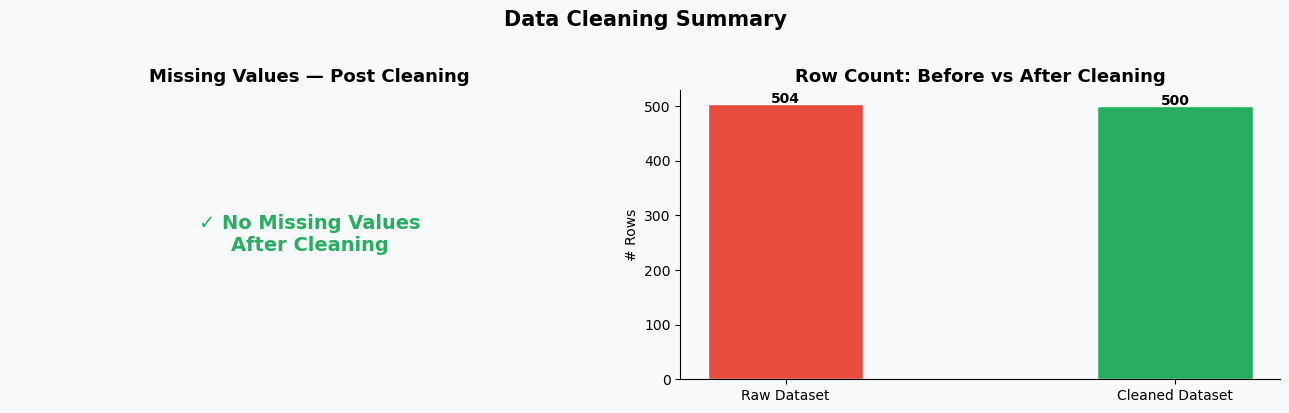

In [9]:
# Cleaning summary visual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Missing after cleaning
remaining_missing = df.isnull().sum().sort_values(ascending=False)
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing):
    axes[0].barh(remaining_missing.index, remaining_missing.values, color='#E74C3C')
    axes[0].set_title('Remaining Missing Values')
else:
    axes[0].text(0.5, 0.5, '✓ No Missing Values\nAfter Cleaning',
                 ha='center', va='center', fontsize=14, color='#27AE60', fontweight='bold',
                 transform=axes[0].transAxes)
    axes[0].set_title('Missing Values — Post Cleaning')
    axes[0].axis('off')

# Row counts: before vs after
bars = axes[1].bar(['Raw Dataset', 'Cleaned Dataset'], [len(df_raw), len(df)],
                   color=['#E74C3C', '#27AE60'], width=0.4, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
axes[1].set_title('Row Count: Before vs After Cleaning')
axes[1].set_ylabel('# Rows')

plt.suptitle('Data Cleaning Summary', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis

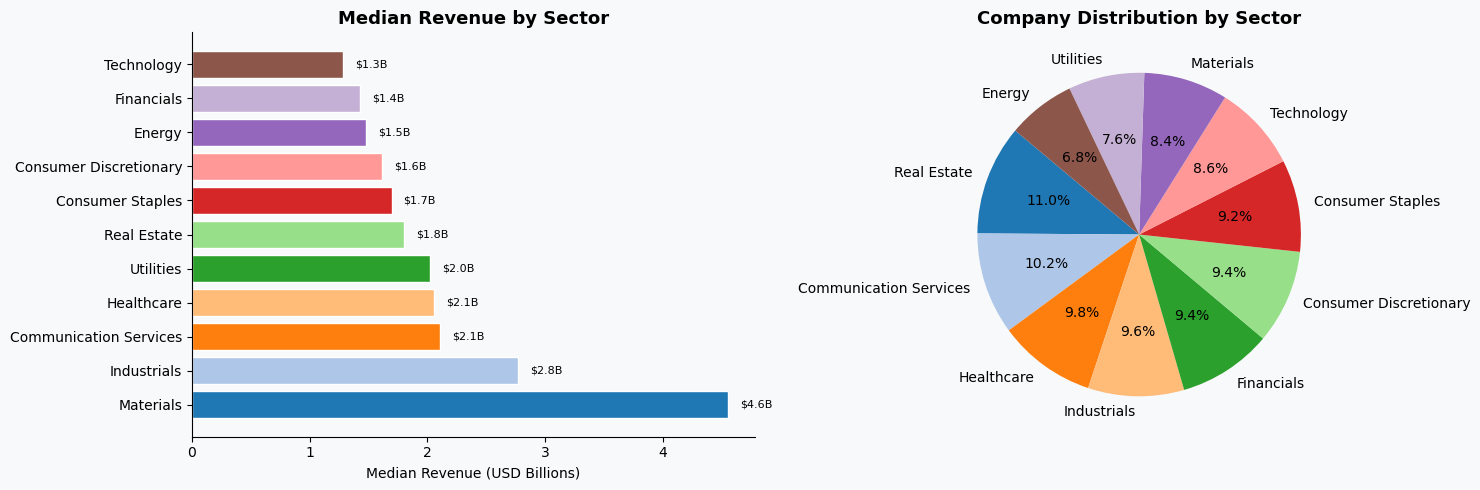

In [10]:
# ── 4.1  Revenue distribution by sector
sector_rev = df.groupby('Sector')['Revenue'].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.tab20.colors[:len(sector_rev)]
bars = axes[0].barh(sector_rev.index, sector_rev.values / 1e9, color=colors, edgecolor='white')
axes[0].set_xlabel('Median Revenue (USD Billions)')
axes[0].set_title('Median Revenue by Sector')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 0.1, bar.get_y() + bar.get_height()/2,
                 f'${w:.1f}B', va='center', fontsize=8)

# Company count per sector
sector_count = df['Sector'].value_counts()
axes[1].pie(sector_count.values, labels=sector_count.index,
            autopct='%1.1f%%', startangle=140,
            colors=plt.cm.tab20.colors[:len(sector_count)])
axes[1].set_title('Company Distribution by Sector')

plt.tight_layout()
plt.show()

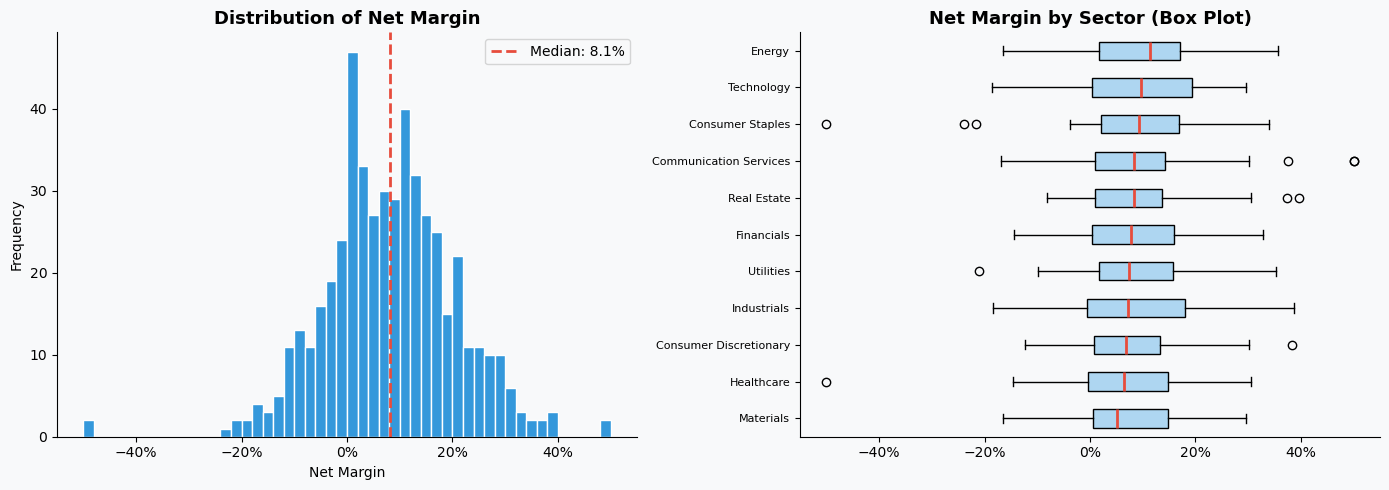

In [11]:
# ── 4.2  Net Margin distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Net_Margin'].clip(-0.5, 0.5), bins=50, color='#3498DB', edgecolor='white')
axes[0].axvline(df['Net_Margin'].median(), color='#E74C3C', lw=2, linestyle='--',
                label=f'Median: {df["Net_Margin"].median():.1%}')
axes[0].set_xlabel('Net Margin')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Net Margin')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend()

# Box plot of net margin by sector
sectors_ordered = df.groupby('Sector')['Net_Margin'].median().sort_values().index.tolist()
data_box = [df[df['Sector'] == s]['Net_Margin'].clip(-0.5, 0.5).values for s in sectors_ordered]
bp = axes[1].boxplot(data_box, vert=False, patch_artist=True,
                     boxprops=dict(facecolor='#AED6F1'),
                     medianprops=dict(color='#E74C3C', linewidth=2))
axes[1].set_yticks(range(1, len(sectors_ordered)+1))
axes[1].set_yticklabels(sectors_ordered, fontsize=8)
axes[1].set_title('Net Margin by Sector (Box Plot)')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

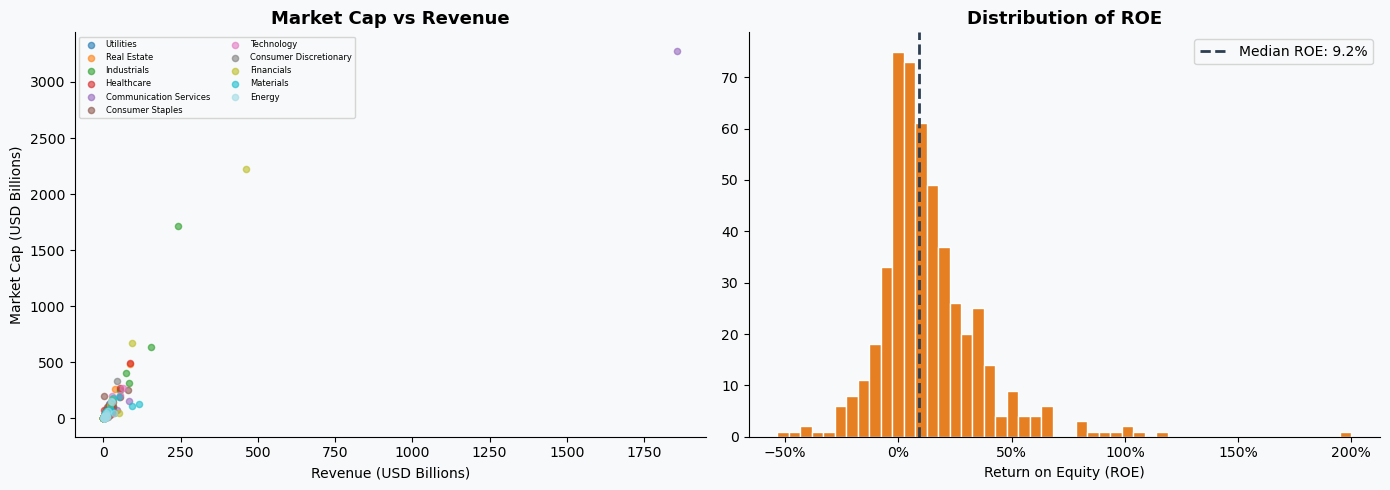

In [12]:
# ── 4.3  Market Cap vs Revenue scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_list = df['Sector'].unique()
cmap = plt.cm.get_cmap('tab20', len(sector_list))
color_map = {s: cmap(i) for i, s in enumerate(sector_list)}

for sector in sector_list:
    subset = df[df['Sector'] == sector]
    axes[0].scatter(subset['Revenue']/1e9, subset['Market_Cap']/1e9,
                    label=sector, alpha=0.6, s=20, color=color_map[sector])

axes[0].set_xlabel('Revenue (USD Billions)')
axes[0].set_ylabel('Market Cap (USD Billions)')
axes[0].set_title('Market Cap vs Revenue')
axes[0].legend(fontsize=6, loc='upper left', ncol=2)

# ROE distribution
roe_clipped = df['ROE'].clip(-1, 2)
axes[1].hist(roe_clipped, bins=50, color='#E67E22', edgecolor='white')
axes[1].axvline(roe_clipped.median(), color='#2C3E50', lw=2, linestyle='--',
                label=f'Median ROE: {roe_clipped.median():.1%}')
axes[1].set_xlabel('Return on Equity (ROE)')
axes[1].set_title('Distribution of ROE')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.show()

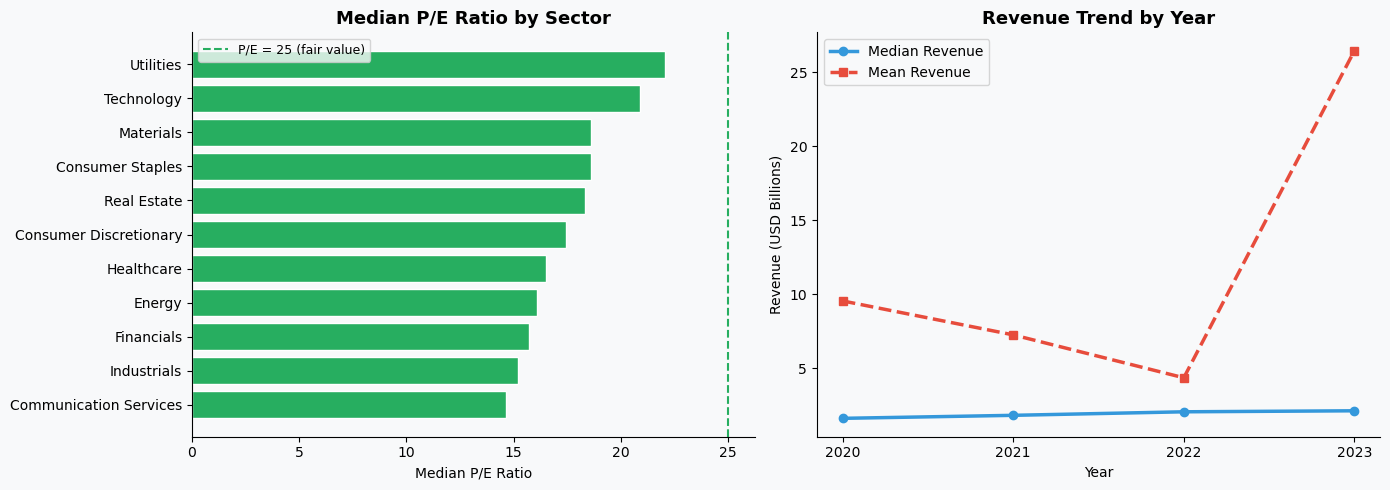

In [13]:
# ── 4.4  PE Ratio analysis & year-wise trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PE by sector (top/bottom 5)
pe_sector = df.groupby('Sector')['PE_Ratio'].median().sort_values()
colors_pe = ['#27AE60' if v < 25 else '#E74C3C' if v > 40 else '#F39C12' for v in pe_sector.values]
bars = axes[0].barh(pe_sector.index, pe_sector.values, color=colors_pe, edgecolor='white')
axes[0].axvline(25, color='#27AE60', lw=1.5, linestyle='--', label='P/E = 25 (fair value)')
axes[0].set_title('Median P/E Ratio by Sector')
axes[0].set_xlabel('Median P/E Ratio')
axes[0].legend(fontsize=9)

# Revenue trend by year
rev_year = df.groupby('Year')['Revenue'].agg(['median', 'mean']) / 1e9
x = rev_year.index.astype(str)
axes[1].plot(x, rev_year['median'], marker='o', lw=2.5, color='#3498DB', label='Median Revenue')
axes[1].plot(x, rev_year['mean'],   marker='s', lw=2.5, color='#E74C3C', linestyle='--', label='Mean Revenue')
axes[1].set_title('Revenue Trend by Year')
axes[1].set_ylabel('Revenue (USD Billions)')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.show()

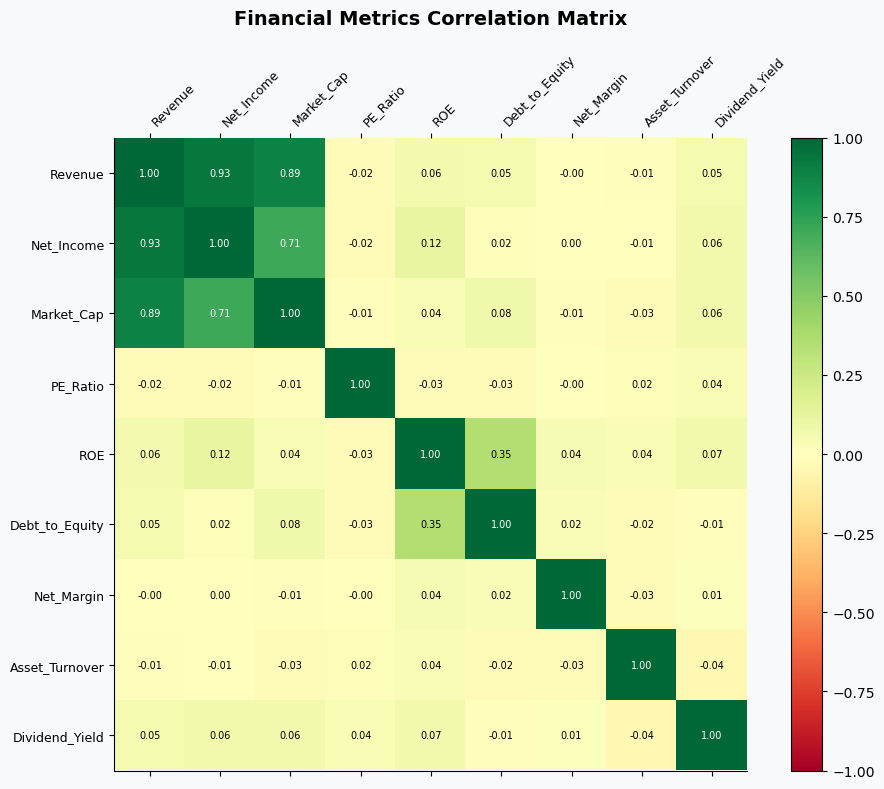

In [14]:
# ── 4.5  Correlation heatmap
corr_cols = ['Revenue','Net_Income','Market_Cap','PE_Ratio','ROE',
             'Debt_to_Equity','Net_Margin','Asset_Turnover','Dividend_Yield']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(cax)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='left', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.7 else 'white')
ax.set_title('Financial Metrics Correlation Matrix', pad=20, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Anomaly & Error Detection

In [15]:
# ── 5.1  IQR-based outlier detection across key metrics
def detect_outliers_iqr(series, label):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((series < lower) | (series > upper)).sum()
    pct    = n_out / len(series) * 100
    return {'Metric': label, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'Lower_Bound': lower, 'Upper_Bound': upper,
            'Outlier_Count': n_out, 'Outlier_%': round(pct, 2)}

metrics = ['Revenue','Net_Income','Market_Cap','PE_Ratio','ROE','Debt_to_Equity','Net_Margin']
outlier_summary = pd.DataFrame([detect_outliers_iqr(df[m], m) for m in metrics])
print('IQR Outlier Detection Summary:')
outlier_summary[['Metric','Outlier_Count','Outlier_%','Lower_Bound','Upper_Bound']].style\
    .background_gradient(subset=['Outlier_%'], cmap='Reds')

IQR Outlier Detection Summary:


,Metric,Outlier_Count,Outlier_%,Lower_Bound,Upper_Bound
0,Revenue,60,12.000000,-6984646305.746410,13122936014.335506
1,Net_Income,97,19.400000,-454927886.711742,766999923.418063
2,Market_Cap,59,11.800000,-33524633874.288376,61147681810.397820
3,PE_Ratio,24,4.800000,-13.248227,49.911483
4,ROE,28,5.600000,-0.314643,0.548547
5,Debt_to_Equity,27,5.400000,-2.522759,6.429636
6,Net_Margin,7,1.400000,-0.222882,0.385265


In [16]:
# ── 5.2  Z-score based outlier detection
from scipy import stats

z_flags = pd.DataFrame(index=df.index)
for m in ['Revenue','PE_Ratio','Debt_to_Equity','Net_Margin']:
    z_flags[f'z_{m}'] = np.abs(stats.zscore(df[m].fillna(df[m].median())))

z_flags['max_z']     = z_flags.max(axis=1)
z_flags['is_anomaly'] = z_flags['max_z'] > 3

print(f'Companies flagged as anomalies (|Z| > 3) : {z_flags["is_anomaly"].sum()}')
anomaly_companies = df[z_flags['is_anomaly']].copy()
anomaly_companies['Max_Z_Score'] = z_flags.loc[z_flags['is_anomaly'], 'max_z'].values
anomaly_companies[['Ticker','Sector','Revenue','PE_Ratio','Debt_to_Equity','Net_Margin','Max_Z_Score']]\
    .sort_values('Max_Z_Score', ascending=False).head(15)

Companies flagged as anomalies (|Z| > 3) : 22


,Ticker,Sector,Revenue,PE_Ratio,Debt_to_Equity,Net_Margin,Max_Z_Score
21,TICK021,Communication Services,2.500000e+06,19.808572,3.193468,69.943722,22.306869
209,TICK209,Communication Services,1.857824e+12,13.596895,3.092305,0.283575,21.177197
111,TICK111,Financials,1.723780e+09,145.030344,1.086657,0.073330,7.512948
327,TICK327,Real Estate,7.517530e+09,132.911209,1.225469,0.017257,6.778602
312,TICK312,Technology,7.988429e+09,129.588766,0.873160,0.253637,6.577282
478,TICK478,Financials,4.613838e+11,19.733340,6.711208,-0.110068,5.156076
380,TICK380,Consumer Discretionary,3.988162e+08,102.982098,0.878166,0.383232,4.965078
350,TICK350,Real Estate,3.164131e+09,89.900324,1.356041,0.005223,4.172402
277,TICK277,Utilities,6.137635e+08,86.031262,4.770275,0.050298,3.937960
447,TICK447,Healthcare,3.330246e+08,14.116832,8.177368,-0.003029,3.151745


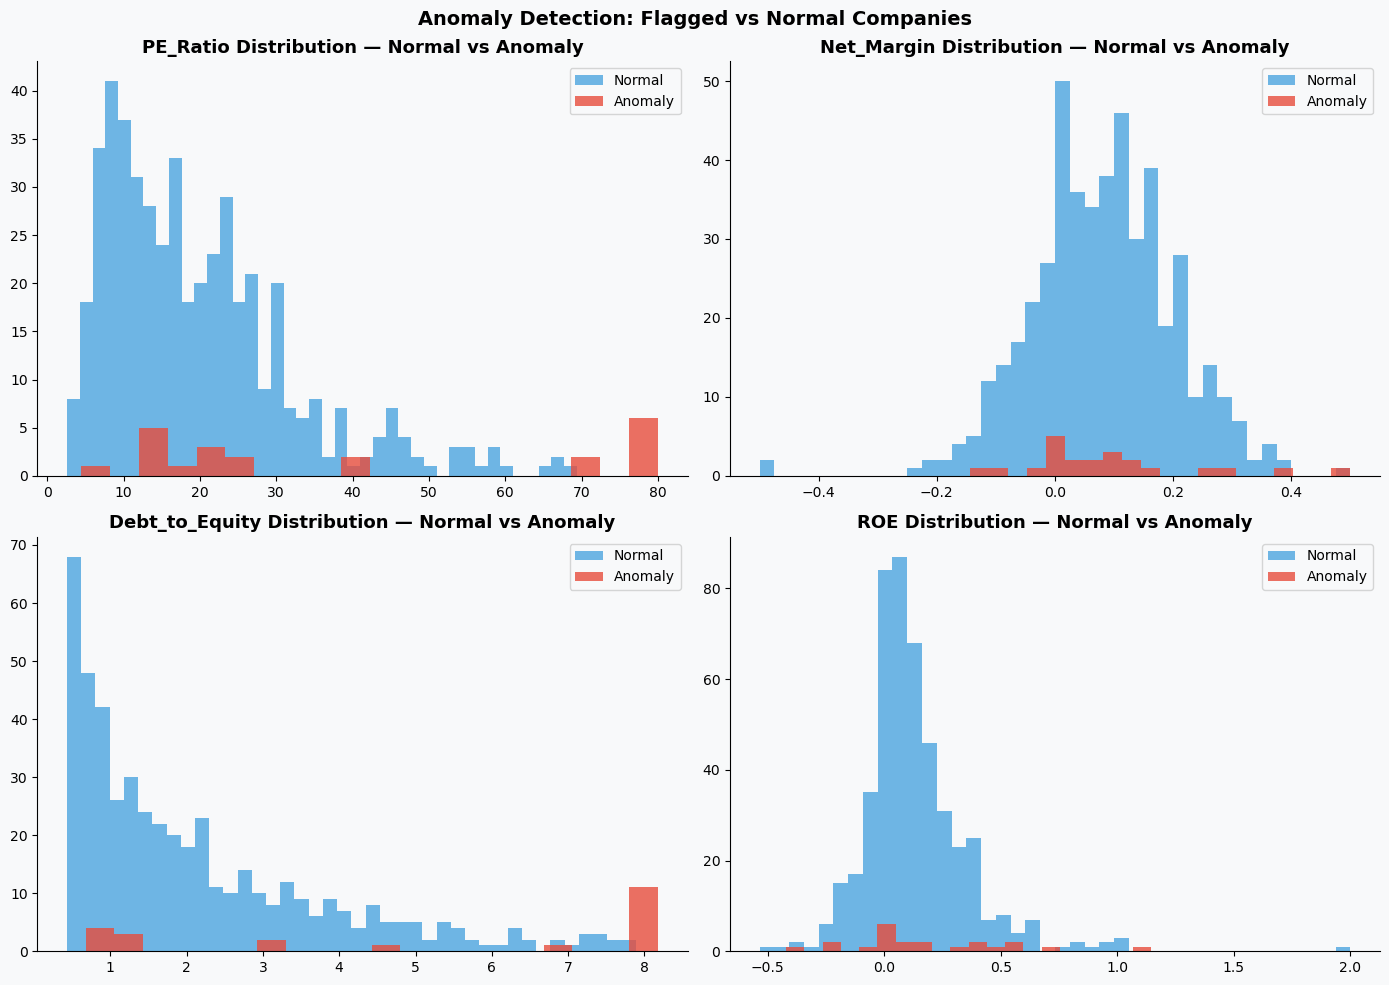

In [17]:
# ── 5.3  Visualise outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_cols = ['PE_Ratio', 'Net_Margin', 'Debt_to_Equity', 'ROE']
clip_vals  = [(0, 80), (-0.5, 0.5), (0, 10), (-1, 2)]

for idx, (col, clip) in enumerate(zip(plot_cols, clip_vals)):
    normal   = df[~z_flags['is_anomaly']][col].clip(*clip)
    anomalous= df[z_flags['is_anomaly']][col].clip(*clip)
    axes[idx].hist(normal,    bins=40, alpha=0.7, color='#3498DB', label='Normal')
    axes[idx].hist(anomalous, bins=20, alpha=0.8, color='#E74C3C', label='Anomaly')
    axes[idx].set_title(f'{col} Distribution — Normal vs Anomaly')
    axes[idx].legend()

plt.suptitle('Anomaly Detection: Flagged vs Normal Companies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ── 5.4  Logical consistency checks  (e.g. Equity = Assets - Liabilities)
df['Equity_Check'] = df['Total_Assets'] - df['Total_Liabilities']
df['Equity_Diff']  = (df['Equity_Check'] - df['Equity']).abs()

threshold = df['Total_Assets'].median() * 0.01
equity_errors = df[df['Equity_Diff'] > threshold]
print(f'Rows where Equity ≠ Assets − Liabilities (tolerance={threshold:,.0f}): {len(equity_errors)}')

# Negative equity
neg_equity = df[df['Equity'] < 0]
print(f'Companies with NEGATIVE equity (technically insolvent): {len(neg_equity)}')
neg_equity[['Ticker','Sector','Total_Assets','Total_Liabilities','Equity']].head()

Rows where Equity ≠ Assets − Liabilities (tolerance=40,618,502): 0
Companies with NEGATIVE equity (technically insolvent): 0


,Ticker,Sector,Total_Assets,Total_Liabilities,Equity


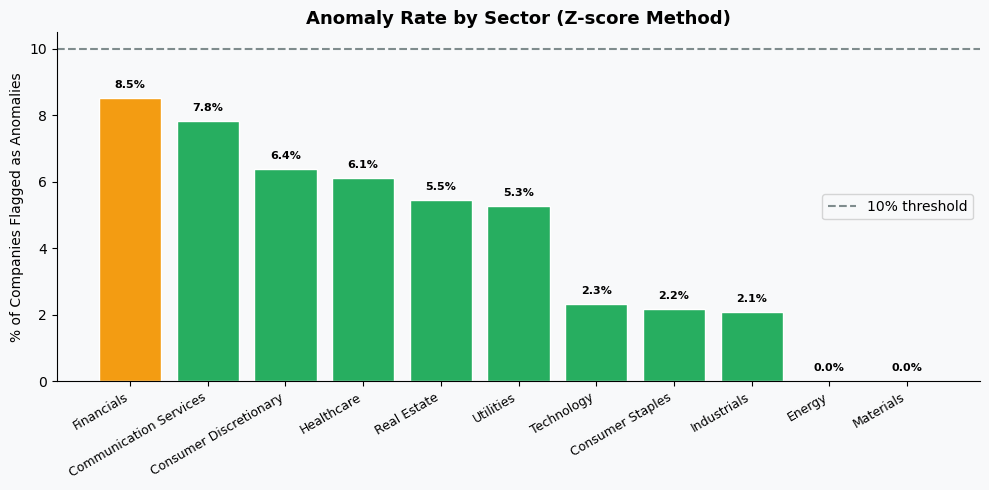

In [19]:
# ── 5.5  Sector-level anomaly heatmap
sector_anomaly = df.copy()
sector_anomaly['is_anomaly'] = z_flags['is_anomaly'].values
anom_rate = sector_anomaly.groupby('Sector')['is_anomaly'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#E74C3C' if v > 0.15 else '#F39C12' if v > 0.08 else '#27AE60' for v in anom_rate.values]
bars = ax.bar(anom_rate.index, anom_rate.values * 100, color=bar_colors, edgecolor='white')
ax.axhline(10, color='#7F8C8D', lw=1.5, linestyle='--', label='10% threshold')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticklabels(anom_rate.index, rotation=30, ha='right', fontsize=9)
ax.set_title('Anomaly Rate by Sector (Z-score Method)')
ax.set_ylabel('% of Companies Flagged as Anomalies')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Key Insights & Summary

In [20]:
# ── Final Summary Statistics
top_rev_sector    = df.groupby('Sector')['Revenue'].median().idxmax()
top_margin_sector = df.groupby('Sector')['Net_Margin'].median().idxmax()
most_overvalued   = df.groupby('Sector')['PE_Ratio'].median().idxmax()
highest_leverage  = df.groupby('Sector')['Debt_to_Equity'].median().idxmax()
anomaly_count     = z_flags['is_anomaly'].sum()
neg_equity_count  = (df['Equity'] < 0).sum()
dup_removed       = int(df_raw.duplicated().sum())

print('=' * 60)
print('          KEY INSIGHTS — FINANCIAL EDA REPORT')
print('=' * 60)

print(f"""
📊 DATASET OVERVIEW
   • Raw records          : {len(df_raw):,}
   • After cleaning       : {len(df):,}
   • Duplicates removed   : {dup_removed}
   • Columns engineered   : 3 (Net_Margin, Asset_Turnover, Equity_Ratio)

⚠️  DATA QUALITY ISSUES FOUND & FIXED
   • Negative Revenue values (data entry errors)   → nullified
   • P/E > 500 (implausible, likely typos)         → nullified
   • Zero / negative Market Cap                     → nullified
   • Dividend Yield > 30% (impossible)              → nullified
   • String contamination in Revenue ('N/A', '$')   → coerced
   • Sector typos (lowercase, abbrev, whitespace)   → standardised
   • Extreme Debt/Equity capped at 99th percentile

🔍 ANOMALY DETECTION
   • Companies flagged (Z-score |z|>3)  : {anomaly_count} ({anomaly_count/len(df)*100:.1f}% of dataset)
   • Companies with negative equity     : {neg_equity_count} (potential insolvency risk)
   • Sector with highest anomaly rate   : {anom_rate.idxmax()} ({anom_rate.max()*100:.1f}%)

💡 FINANCIAL INSIGHTS
   • Highest-revenue sector (median)    : {top_rev_sector}
   • Best net margin sector             : {top_margin_sector} ({df[df['Sector']==top_margin_sector]['Net_Margin'].median():.1%})
   • Most overvalued sector (P/E)       : {most_overvalued} (median P/E = {df[df['Sector']==most_overvalued]['PE_Ratio'].median():.1f}x)
   • Highest leverage sector            : {highest_leverage} (Debt/Eq = {df[df['Sector']==highest_leverage]['Debt_to_Equity'].median():.2f}x)
   • Overall median Net Margin          : {df['Net_Margin'].median():.1%}
   • Overall median ROE                 : {df['ROE'].median():.1%}
   • Revenue & Market Cap are strongly correlated (r ≈ {df['Revenue'].corr(df['Market_Cap']):.2f})
   • Net Margin and ROE are positively correlated (r ≈ {df['Net_Margin'].corr(df['ROE']):.2f})
""")
print('=' * 60)

          KEY INSIGHTS — FINANCIAL EDA REPORT

📊 DATASET OVERVIEW
   • Raw records          : 504
   • After cleaning       : 500
   • Duplicates removed   : 4
   • Columns engineered   : 3 (Net_Margin, Asset_Turnover, Equity_Ratio)

⚠️  DATA QUALITY ISSUES FOUND & FIXED
   • Negative Revenue values (data entry errors)   → nullified
   • P/E > 500 (implausible, likely typos)         → nullified
   • Zero / negative Market Cap                     → nullified
   • Dividend Yield > 30% (impossible)              → nullified
   • String contamination in Revenue ('N/A', '$')   → coerced
   • Sector typos (lowercase, abbrev, whitespace)   → standardised
   • Extreme Debt/Equity capped at 99th percentile

🔍 ANOMALY DETECTION
   • Companies flagged (Z-score |z|>3)  : 22 (4.4% of dataset)
   • Companies with negative equity     : 0 (potential insolvency risk)
   • Sector with highest anomaly rate   : Financials (8.5%)

💡 FINANCIAL INSIGHTS
   • Highest-revenue sector (median)    : Materials
   •

In [21]:
# ── Final: Export cleaned dataset
df.drop(columns=['Equity_Check', 'Equity_Diff'], inplace=True, errors='ignore')
df.to_csv('sp500_cleaned.csv', index=False)
print(f'Cleaned dataset saved → sp500_cleaned.csv  ({len(df)} rows × {df.shape[1]} columns)')

Cleaned dataset saved → sp500_cleaned.csv  (500 rows × 18 columns)
